In [201]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from typing import Annotated
from dotenv import load_dotenv
from pydantic import BaseModel
import os 
from langchain_groq import ChatGroq
from langchain.tools import tool


load_dotenv()

True

In [202]:
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [203]:
llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0.9)

In [204]:
class State(BaseModel):
    messages: Annotated[list, add_messages]
    user_query: str
    query: str | None = None
    validation: str | None = None
    error: str | None = None
    result: str | None = None
    retries: int = 0

In [205]:
schema="epm"
database="epm"
table_name="group_monitoring"
columns=[
                {
                    "name": "time",
                    "type": "timestamp",
                    "original_type": "DateTime",
                    "is_nullable": False,
                    "default_value": "",
                    "is_primary_key": True,
                    "is_numeric": False
                },
                {
                    "name": "groupName",
                    "type": "string",
                    "original_type": "LowCardinality(String)",
                    "is_nullable": False,
                    "default_value": "",
                    "is_primary_key": False,
                    "is_numeric": False
                },
                {
                    "name": "cameraId",
                    "type": "string",
                    "original_type": "String",
                    "is_nullable": False,
                    "default_value": "",
                    "is_primary_key": True,
                    "is_numeric": False
                },
                {
                    "name": "location",
                    "type": "string",
                    "original_type": "LowCardinality(String)",
                    "is_nullable": False,
                    "default_value": "",
                    "is_primary_key": True,
                    "is_numeric": False
                },
                {
                    "name": "areaName",
                    "type": "string",
                    "original_type": "LowCardinality(String)",
                    "is_nullable": False,
                    "default_value": "",
                    "is_primary_key": True,
                    "is_numeric": False
                },
                {
                    "name": "category",
                    "type": "string",
                    "original_type": "LowCardinality(String)",
                    "is_nullable": False,
                    "default_value": "",
                    "is_primary_key": False,
                    "is_numeric": False
                },
                {
                    "name": "subCategory",
                    "type": "string",
                    "original_type": "LowCardinality(String)",
                    "is_nullable": False,
                    "default_value": "",
                    "is_primary_key": False,
                    "is_numeric": False
                },
                {
                    "name": "label",
                    "type": "string",
                    "original_type": "LowCardinality(String)",
                    "is_nullable": False,
                    "default_value": "",
                    "is_primary_key": True,
                    "is_numeric": False
                },
                {
                    "name": "latitude",
                    "type": "float",
                    "original_type": "Float64",
                    "is_nullable": False,
                    "default_value": "",
                    "is_primary_key": False,
                    "is_numeric": True
                },
                {
                    "name": "longitude",
                    "type": "float",
                    "original_type": "Float64",
                    "is_nullable": False,
                    "default_value": "",
                    "is_primary_key": False,
                    "is_numeric": True
                },
                {
                    "name": "count",
                    "type": "integer",
                    "original_type": "UInt32",
                    "is_nullable": False,
                    "default_value": "",
                    "is_primary_key": False,
                    "is_numeric": True
                },
                {
                    "name": "date",
                    "type": "timestamp",
                    "original_type": "Date",
                    "is_nullable": False,
                    "default_value": "toDate(time)",
                    "is_primary_key": False,
                    "is_numeric": False
                },
                {
                    "name": "__total_count",
                    "type": "integer",
                    "original_type": "aggregate_function",
                    "is_nullable": False,
                    "default_value": None,
                    "is_primary_key": False,
                    "is_numeric": True,
                    "isGenerated": True
                }
            ]

In [206]:
from typing import Optional
from langchain_core.messages import SystemMessage, HumanMessage
from pydantic import BaseModel

class QueryState(BaseModel):
    query: str

prompt = """
You are an expert SQL query generator specialized in ClickHouse.

## Datasource
- Engine: ClickHouse (SQL dialect)
- Database: {database}
- Table: {table_name}
- Columns: {columns}

## Task
Convert the user's natural language request into a valid ClickHouse SQL query.

## Rules
1. Return only the raw SQL query. No explanations, no markdown, no code fences.
2. Always apply LIMIT 100 unless the user explicitly requests a different limit.
3. For non-aggregated queries, use ORDER BY time DESC unless the user specifies a different sort order.
4. For aggregated queries, use a sensible ORDER BY based on the grouped field or alias.
5. Use ClickHouse-specific syntax where applicable.
6. Only use column names from this list: {columns}.
7. Never guess, infer, or hallucinate column names.
8. Always qualify the table as {database}.{table_name}.
9. Prefer WHERE over HAVING unless aggregation filtering is required.
10. Never generate INSERT, UPDATE, DELETE, DROP, ALTER, TRUNCATE, or any non-SELECT statement.
11. If the user asks for a non-SELECT operation, return exactly:
Only SELECT queries are supported.
"""

sys_msg = SystemMessage(content=prompt.format(
    database=schema,
    table_name=table_name,
    columns=columns
))

def texttosql(state: State):
    # Case 1: first-time generation
    if not state.error:
        user_msg = HumanMessage(content=state.user_query)
        result = llm.invoke([sys_msg, user_msg])
        sql = result.content.strip()

        return {
            "messages": state.messages + [result],
            "query": sql
        }

    # Case 2: retry after query failure
    retry_msg = HumanMessage(content=f"""
The previous SQL query failed.

Original user request:
{state.user_query}

Previous SQL query:
{state.query}

Database error:
{state.error}

Generate a corrected ClickHouse SQL query.

Return only the raw SQL query.
Do not include explanations, markdown, or code fences.
""")

    result = llm.invoke([sys_msg, retry_msg])
    sql = result.content.strip()

    return {
        "messages": state.messages + [result],
        "query": sql
    }

In [207]:
import clickhouse_connect

client = clickhouse_connect.get_client(host='localhost', port=8123, username='masterworks', password='Masterworks@123', database="epm")

In [208]:
def validator(state: State):
    try:
        result = client.query(state.query)
        return {
            "validation": "valid",
            "error": None,
            "result": str(result.result_rows),
        }
    except Exception as e:
        return {
            "validation": "invalid",
            "error": str(e),
            "result": None,
            "retries": state.retries + 1
        }

In [209]:
workflow = StateGraph(State)

# Nodes
workflow.add_node("texttosql", texttosql)
workflow.add_node("validator", validator)

# Flow
workflow.add_edge(START, "texttosql")
workflow.add_edge("texttosql", "validator")


def route_after_validation(state: State):
    if state.validation == "valid":
        return "end"
    elif state.retries < 3:
        return "retry"
    else:
        return "end"


workflow.add_conditional_edges(
    "validator",
    route_after_validation,
    {
        "retry": "texttosql",
        "end": END,
    }
)

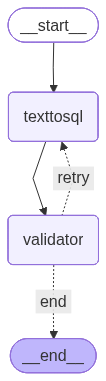

================================ Human Message =================================

Show hourly trend of counts for camera "CAM_005" over the last 3 days
None
================================== Ai Message ==================================

SELECT toStartOfHour(time) AS hour, sum(count) AS total_count FROM epm.group_monitoring WHERE cameraId = 'CAM_005' AND time >= now() - INTERVAL 3 DAY GROUP BY hour ORDER BY hour ASC LIMIT 100
None
Generated SQL Query: SELECT toStartOfHour(time) AS hour, sum(count) AS total_count FROM epm.group_monitoring WHERE cameraId = 'CAM_005' AND time >= now() - INTERVAL 3 DAY GROUP BY hour ORDER BY hour ASC LIMIT 100


In [210]:
from IPython.display import Image, display
graph  = workflow.compile()

state = graph.invoke({
    "messages": [HumanMessage(content='Show hourly trend of counts for camera "CAM_005" over the last 3 days')],
    "user_query": 'Show hourly trend of counts for camera "CAM_005" over the last 3 days',
    "query": None,
    "error": None,
    "validation": None,
    "result": None,
    "retries": 0
})

display(Image(graph.get_graph().draw_mermaid_png()))
for m in state["messages"]:
    print(m.pretty_print())

print(f"Generated SQL Query: {state['query']}")